In [ ]:
import zipfile
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
zip_path = "DL_Dataset.zip"
extract_path = "dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset unzipped")

Dataset unzipped


In [ ]:
data = []
labels = []
IMG_SIZE = 24

base_data_path = os.path.join(extract_path, "Digit Dataset")

for label in range(10):
    folder_path = os.path.join(base_data_path, str(label) + "-digit")

    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        _, img = cv2.threshold(img, 100, 255, cv2.THRESH_BINARY)
        img = 255 - img

        data.append(img)
        labels.append(label)

X = np.array(data).astype('float32') / 255.0
y = np.array(labels)

print("Dataset loaded:", X.shape)

Dataset loaded: (200, 24, 24)


In [ ]:
X = X.reshape(-1, 24, 24, 1)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

In [ ]:
model = keras.Sequential([
    keras.layers.Input(shape=(24,24,1)),

    keras.layers.Conv2D(32, (3,3), activation='relu'),
    keras.layers.MaxPooling2D(),

    keras.layers.Conv2D(64, (3,3), activation='relu'),
    keras.layers.MaxPooling2D(),

    keras.layers.Flatten(),

    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
datagen = ImageDataGenerator()
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=30,
    validation_data=(X_test, y_test)
)

Epoch 1/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 396ms/step - accuracy: 0.1063 - loss: 2.2868 - val_accuracy: 0.2000 - val_loss: 2.2610
Epoch 2/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3375 - loss: 2.1543 - val_accuracy: 0.2750 - val_loss: 2.1722
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5312 - loss: 1.9785 - val_accuracy: 0.4250 - val_loss: 1.9937
Epoch 4/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6062 - loss: 1.7205 - val_accuracy: 0.4500 - val_loss: 1.7768
Epoch 5/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6187 - loss: 1.4297 - val_accuracy: 0.4500 - val_loss: 1.5677
Epoch 6/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6938 - loss: 1.1813 - val_accuracy: 0.5000 - val_loss: 1.4123
Epoch 7/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7812 - loss: 0.9067 - val_accuracy: 0.5750 - val_loss: 1.2820
Epoch 8/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8062 - loss: 0.7555 - val_accuracy: 0.6000 - val_loss: 1.1979

In [ ]:
loss, acc = model.evaluate(X_test, y_test)
print("\n Accuracy:", acc)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7000 - loss: 1.0208

 Accuracy: 0.699999988079071


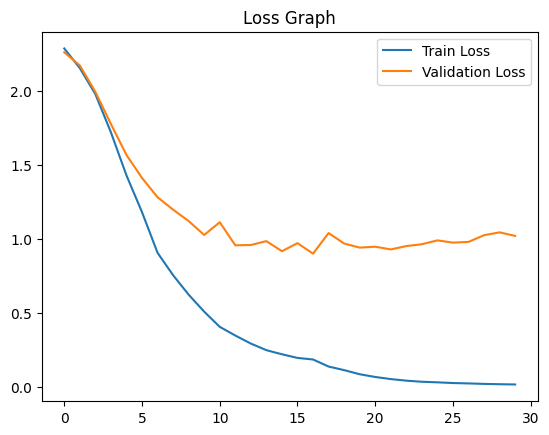

In [ ]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Graph")
plt.show()

In [ ]:
y_pred = np.argmax(model.predict(X_test), axis=1)

print("\n Classification Report (Precision, Recall, F1-score):")
print(classification_report(y_test, y_pred))

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 300ms/step

 Classification Report (Precision, Recall, F1-score):
              precision    recall  f1-score   support

           0       0.67      1.00      0.80         4
           1       1.00      1.00      1.00         1
           2       0.40      0.67      0.50         3
           3       0.60      0.33      0.43         9
           4       0.80      1.00      0.89         4
           5       1.00      0.50      0.67         2
           6       0.71      0.83      0.77         6
           7       1.00      0.50      0.67         4
           8       0.80      0.80      0.80         5
           9       0.67      1.00      0.80         2

    accuracy                           0.70        40
   macro avg       0.76      0.76      0.73        40
weighted avg       0.73      0.70      0.68        40



In [ ]:
pred = model.predict(X_test[:10])

print("\nPredicted:", np.argmax(pred, axis=1))
print("Actual   :", y_test[:10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 494ms/step

Predicted: [4 0 1 8 6 5 6 3 8 3]
Actual   : [4 0 1 7 6 5 3 8 8 2]


In [ ]:
img = cv2.imread("/test.jpeg", cv2.IMREAD_GRAYSCALE)

img = cv2.resize(img, (24, 24))
_, img = cv2.threshold(img, 100, 255, cv2.THRESH_BINARY)
img = 255 - img

img = img.astype('float32') / 255.0
img = img.reshape(1, 24, 24, 1)

pred = model.predict(img)

print("\nPredicted:", np.argmax(pred, axis=1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step

Predicted: [9]
